#Isoform Diversity (Rényi entropy)

Quantify per-gene isoform diversity across cell types and tissues using **Rényi entropy of order α** of isoform usage (recollapsed counts).

Rényi entropy generalizes Shannon entropy:
$$H_\alpha = \frac{1}{1-\alpha} \log_2 \left( \sum_i IF_i^{\,\alpha} \right)$$

Special cases:
- α → 0: Hartley (max) entropy, $\log_2 N_{iso}$ — counts isoforms regardless of usage
- α → 1: Shannon entropy (used in `04a`)
- α = 2: Collision entropy, $-\log_2 \sum_i IF_i^2$ — related to the Simpson/Gini index
- α → ∞: Min-entropy, $-\log_2 \max_i IF_i$ — dominated by the most abundant isoform

Larger α down-weights low-frequency isoforms; smaller α treats all expressed isoforms more equally. This notebook uses **α = 2** by default (set via `RENYI_ALPHA`).

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# Rényi entropy order (alpha). 2 = collision entropy.
RENYI_ALPHA = 2

# Restrict the ENTIRE analysis to protein-coding genes only (set True to enable).
# Applied once at load time (filters adata's isoform columns), so it propagates to
# every downstream cell. Protein-coding genes = those with >=1 protein-coding transcript
# in csvs/transcripts_to_genes_with_biotypes.txt (gene_biotype == "protein_coding").
PROTEIN_CODING_ONLY = False

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True


#3. Per-gene Rényi entropy ($H_\alpha$) of isoform usage per cell type

For each gene in each cell type, compute the mean isoform fraction across cells, then the Rényi entropy of order α:

$$H_\alpha = \frac{1}{1-\alpha} \log_2 \left( \sum_i IF_i^{\,\alpha} \right) \quad (\alpha \neq 1)$$

$H_\alpha$ ranges from 0 (one dominant isoform) to $\log_2 (n_{isoforms})$ (perfectly even usage, achieved as α → 0). Unlike Pielou's J, $H_\alpha$ is not normalized by the number of isoforms, so genes with more isoforms can reach higher values.


In [3]:
# Read appropiate adata with isofracs

In [4]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")

# Determine gene column
gene_col = "associated_gene" if "associated_gene" in adata.var.columns else "gene_name"
print(f"Using gene column: {gene_col}")

# Optional: keep only isoforms from protein-coding genes (toggle PROTEIN_CODING_ONLY at top)
if PROTEIN_CODING_ONLY:
    _ref = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
    _pc = _ref.loc[_ref["gene_biotype"].astype(str) == "protein_coding"]
    _pc_names = set(_pc["gene_name"].dropna().astype(str))
    _pc_ids = set(_pc["gene_id"].astype(str).str.replace(r"\..*", "", regex=True))
    keep = np.zeros(adata.shape[1], dtype=bool)
    if "gene_name" in adata.var.columns:
        keep |= adata.var["gene_name"].astype(str).isin(_pc_names).to_numpy()
    if "associated_gene" in adata.var.columns:
        _ensg = adata.var["associated_gene"].astype(str).str.replace(r"\..*", "", regex=True)
        keep |= _ensg.isin(_pc_ids).to_numpy()
    if not keep.any():   # fall back to whatever gene_col holds
        keep |= adata.var[gene_col].astype(str).isin(_pc_names | _pc_ids).to_numpy()
    n_before = adata.shape[1]
    adata = adata[:, keep].copy()
    print(f"PROTEIN_CODING_ONLY: kept {adata.shape[1]}/{n_before} isoform features "
          f"({adata.var[gene_col].nunique()} genes)")
else:
    print("PROTEIN_CODING_ONLY = False (using all genes)")

adata

Using gene column: gene_name
PROTEIN_CODING_ONLY = False (using all genes)


AnnData object with n_obs × n_vars = 203311 × 478192
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class'
    var: 'transcript_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'isoform_fraction'

In [5]:
from scipy.sparse import csc_matrix as _csc_matrix

def renyi_entropy(fracs, alpha=RENYI_ALPHA):
    """Compute Rényi entropy of order alpha from an array of fractions (summing to ~1).

    H_alpha = 1/(1-alpha) * log2(sum(p^alpha)) for alpha != 1.
    Reduces to Shannon entropy in the alpha -> 1 limit.
    """
    fracs = fracs[fracs > 0]
    if len(fracs) == 0:
        return 0.0
    if np.isclose(alpha, 1.0):
        return float(-np.sum(fracs * np.log2(fracs)))
    if np.isinf(alpha):
        return float(-np.log2(np.max(fracs)))
    s = np.sum(np.power(fracs, alpha))
    return float(np.log2(s) / (1.0 - alpha))

frac_mat = adata.layers["isoform_fraction"]
genes = adata.var[gene_col].values

# Build isoform-to-gene mapping matrix for vectorized n_expr computation
unique_genes, gene_indices = np.unique(genes, return_inverse=True)
n_genes_unique = len(unique_genes)
n_isoforms = len(genes)

# Sparse matrix (n_isoforms x n_genes): multiplying binary expression matrix
# by this yields per-gene expression counts per cell
iso_to_gene = _csc_matrix(
    (np.ones(n_isoforms, dtype=np.float32), (np.arange(n_isoforms), gene_indices)),
    shape=(n_isoforms, n_genes_unique)
)

# Precompute column indices per gene for fast numpy slicing
gene_col_indices = [np.where(gene_indices == g)[0] for g in range(n_genes_unique)]

# Convert to CSC for efficient column-sum operations
if issparse(frac_mat):
    frac_csc = frac_mat.tocsc()
else:
    frac_csc = frac_mat

In [5]:
cell_types = sorted([ct for ct in adata.obs["cell_ontology_class"].unique() if ct != "unknown"])
print(f"Computing Rényi entropy (alpha={RENYI_ALPHA}) for {n_genes_unique} genes x {len(cell_types)} cell types")

entropy_records = []
for ct_i, ct in enumerate(cell_types):
    ct_mask = (adata.obs["cell_ontology_class"] == ct).values
    n_cells_ct = ct_mask.sum()
    if n_cells_ct < 10:
        continue

    frac_ct = frac_csc[ct_mask, :]

    # Column sums: total isoform fraction per isoform across all cells of this type
    col_sums = np.asarray(frac_ct.sum(axis=0)).ravel()

    # Number of expressing cells per gene via sparse matmul
    gene_expr_per_cell = (frac_ct > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    # Compute Rényi entropy per gene
    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) == 0:
            continue
        n_expressed = int(len(mean_fracs))   # isoforms with nonzero mean usage (H is computed over these)
        H = renyi_entropy(mean_fracs, alpha=RENYI_ALPHA)
        entropy_records.append({"gene": unique_genes[g_idx], "cell_ontology_class": ct, "entropy": H,
                                 "n_isoforms": n_iso, "n_expressed_isoforms": n_expressed,
                                 "n_cells_expr": n_expr})

    if (ct_i + 1) % 20 == 0:
        print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")

print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")
entropy_df = pd.DataFrame(entropy_records)
print(f"Entropy table: {entropy_df.shape[0]} gene-celltype pairs")
print(f"Rényi entropy (alpha={RENYI_ALPHA}) range: [{entropy_df['entropy'].min():.4f}, {entropy_df['entropy'].max():.4f}]")
entropy_df.head(10)

Computing Rényi entropy (alpha=2) for 26940 genes x 144 cell types
  Processed 20 / 144 cell types
  Processed 40 / 144 cell types
  Processed 60 / 144 cell types
  Processed 80 / 144 cell types
  Processed 100 / 144 cell types
  Processed 120 / 144 cell types
  Processed 144 / 144 cell types
Entropy table: 1092139 gene-celltype pairs
Rényi entropy (alpha=2) range: [-0.0000, 5.5572]


,gene,cell_ontology_class,entropy,n_isoforms,n_expressed_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1,1106
1,A1BG,acinar cell of salivary gland,0.065061,9,2,133
2,A1BG-AS1,acinar cell of salivary gland,1.874469,20,6,11
3,A2M,acinar cell of salivary gland,0.614561,43,12,357
4,A4GALT,acinar cell of salivary gland,1.245926,22,11,162
5,AAAS,acinar cell of salivary gland,1.585186,24,11,127
6,AACS,acinar cell of salivary gland,1.388013,14,9,183
7,AAGAB,acinar cell of salivary gland,1.997504,18,6,76
8,AAK1,acinar cell of salivary gland,0.187266,32,10,396
9,AAMDC,acinar cell of salivary gland,2.690907,83,33,191


In [6]:
# Save per-gene per-cell-type isoform diversity (Rényi entropy H_alpha)
_csv_path = f"./../csvs/per_gene_celltype_isoform_diversity_renyi_H_alpha{RENYI_ALPHA}.csv"
entropy_df.to_csv(_csv_path, index=False)
print(f"Saved {entropy_df.shape[0]} gene-celltype pairs to {_csv_path}")
entropy_df.head()

Saved 1092139 gene-celltype pairs to ./../csvs/per_gene_celltype_isoform_diversity_renyi_H_alpha2.csv


,gene,cell_ontology_class,entropy,n_isoforms,n_expressed_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1,1106
1,A1BG,acinar cell of salivary gland,0.065061,9,2,133
2,A1BG-AS1,acinar cell of salivary gland,1.874469,20,6,11
3,A2M,acinar cell of salivary gland,0.614561,43,12,357
4,A4GALT,acinar cell of salivary gland,1.245926,22,11,162


#4. Rank genes by isoform diversity

In [6]:
_csv_path = f"./../csvs/per_gene_celltype_isoform_diversity_renyi_H_alpha{RENYI_ALPHA}.csv"
entropy_df = pd.read_csv(_csv_path)
entropy_df.head()

,gene,cell_ontology_class,entropy,n_isoforms,n_expressed_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1,1106
1,A1BG,acinar cell of salivary gland,0.065061,9,2,133
2,A1BG-AS1,acinar cell of salivary gland,1.874469,20,6,11
3,A2M,acinar cell of salivary gland,0.614561,43,12,357
4,A4GALT,acinar cell of salivary gland,1.245926,22,11,162


In [7]:
# Mean Rényi entropy across cell types per gene
gene_entropy = entropy_df.groupby("gene")["entropy"].agg(["mean", "std", "count"]).reset_index()
gene_entropy.columns = ["gene", "mean_entropy", "std_entropy", "n_celltypes"]
gene_entropy = gene_entropy.sort_values("mean_entropy", ascending=False)

print("Top 20 highest isoform diversity genes (by Rényi entropy $H_\\alpha$):")
print(gene_entropy.head(20).to_string(index=False))

print("\nTop 20 lowest isoform diversity genes (>= 5 cell types):")
low_div = gene_entropy[gene_entropy["n_celltypes"] >= 5].sort_values("mean_entropy")
print(low_div.head(20).to_string(index=False))

# Distribution of number of isoforms per gene
isoforms_per_gene = adata.var[gene_col].value_counts()
median_iso = isoforms_per_gene.median()
mean_iso = isoforms_per_gene.mean()
print(f"\nIsoforms per gene: median={median_iso:.0f}, mean={mean_iso:.1f}")

Top 20 highest isoform diversity genes (by Rényi entropy $H_\alpha$):
              gene  mean_entropy  std_entropy  n_celltypes
         LARGE-AS1      4.425432     0.043220            2
         LINC01667      4.393085     0.102096            2
CEP164P1+ZNF22-AS1      4.232525     0.147703            2
          MAP9-AS1      4.118655     0.140296            2
             LRRD1      4.052915     0.107082            2
              DMKN      4.036365     1.009288           75
             ADAM5      3.988460     0.016538            2
         CRPPA-AS1      3.973935     0.047060            2
        ADGRL3-AS1      3.962688     0.130087            2
            MGAT4C      3.962210     0.028328            2
           FAM228B      3.939652     1.010082           91
         LINC01584      3.884873     0.012024            2
         LINC02436      3.876953     0.010734            2
         LINC00917      3.871435     0.327085            2
        PCED1B-AS1      3.861598     0.981299

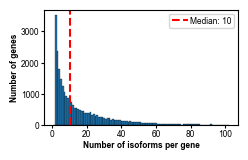

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


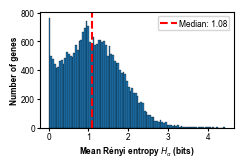

In [8]:
fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.hist(isoforms_per_gene.values, bins=np.arange(0.5, isoforms_per_gene.quantile(0.99) + 1.5, 1),
        edgecolor="black", linewidth=0.2)
ax.set_xlabel("Number of isoforms per gene")
ax.set_ylabel("Number of genes")
# ax.set_title("Distribution of isoforms per gene")
ax.axvline(median_iso, color="red", linestyle="--",
           label=f"Median: {median_iso:.0f}")
ax.legend()
plt.savefig(figpath("04_05_isoforms_per_gene_distribution.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.hist(gene_entropy["mean_entropy"], bins=100, edgecolor="black", linewidth=0.2)
ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_ylabel("Number of genes")
# ax.set_title("Distribution of per-gene isoform diversity")
ax.axvline(gene_entropy["mean_entropy"].median(), color="red", linestyle="--",
           label=f"Median: {gene_entropy['mean_entropy'].median():.2f}")
ax.legend()
plt.savefig(figpath("renyi_entropy_distribution.pdf"))


#5. Compare entropy across cell types

In [24]:
# cell_ontology_class -> broad_cell_class map (same mapping CSVs as section 7 / 01_08)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

_ent = entropy_df.copy()
_ent["broad_cell_class"] = _ent["cell_ontology_class"].map(
    lambda ct: ts_broad_map.get(ct, "unknown"))

# Mean number of isoforms per gene, by broad cell class (horizontal bars)
broad_mean_n_isoforms = _ent.groupby("broad_cell_class")["n_isoforms"].mean().sort_values(ascending=True)
median_broad_iso = broad_mean_n_isoforms.median()

# Mean Rényi entropy by broad cell class (horizontal bars)
broad_mean_entropy = _ent.groupby("broad_cell_class")["entropy"].mean().sort_values(ascending=True)
median_broad_entropy = broad_mean_entropy.median()


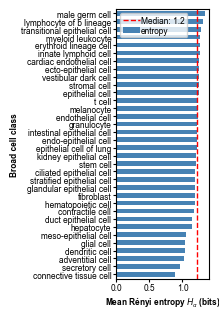

In [26]:
# fig, ax = plt.subplots(figsize=(6, 6))
# broad_mean_n_isoforms.plot(kind="barh", ax=ax, color="steelblue", width=0.9)
# ax.axvline(median_broad_iso, color="red", linestyle="--", label=f"Median: {median_broad_iso:.1f}")
# ax.set_xlabel("Mean number of molecules (per gene)")
# ax.set_ylabel("Broad cell class")
# ax.margins(y=0.005)
# ax.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(4.5, 1.2))
# broad_mean_entropy.plot(kind="bar", ax=ax, color="steelblue", width=0.6)
# ax.axhline(median_broad_entropy, color="red", linestyle="--", label=f"Median: {median_broad_entropy:.1f}")
# ax.set_ylabel("Mean Rényi entropy $H_\\alpha$ (bits)")
# ax.set_xlabel("Broad cell class")
# plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# # ax.margins(y=0.005)
# ax.legend()
# plt.savefig(figpath("renyi_acorss_celltypes.pdf"))

fig, ax = plt.subplots(figsize=(1.2, 3.5))
broad_mean_entropy.plot(kind="barh", ax=ax, color="steelblue", width=0.6)
ax.axvline(median_broad_entropy, color="red", linestyle="--", linewidth = 1.0, label=f"Median: {median_broad_entropy:.1f}")
ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_ylabel("Broad cell class")
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")
# ax.margins(y=0.005)
ax.legend()
plt.savefig(figpath("renyi_acorss_celltypes.pdf"))


#6. Compare entropy across tissues

In [27]:
# Compute Rényi entropy per gene per tissue (reuses frac_csc, iso_to_gene, gene_col_indices from above)
tissues = sorted(adata.obs["tissue"].unique())
tissue_entropy_records = []
for t_i, tissue in enumerate(tissues):
    t_mask = (adata.obs["tissue"] == tissue).values
    if t_mask.sum() < 10:
        continue

    frac_t = frac_csc[t_mask, :]
    col_sums = np.asarray(frac_t.sum(axis=0)).ravel()
    gene_expr_per_cell = (frac_t > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) == 0:
            continue
        H = renyi_entropy(mean_fracs, alpha=RENYI_ALPHA)
        tissue_entropy_records.append({"gene": unique_genes[g_idx], "tissue": tissue,
                                        "entropy": H, "n_isoforms": n_iso})

    print(f"  Tissue {t_i + 1}/{len(tissues)}: {tissue}")

tissue_entropy_df = pd.DataFrame(tissue_entropy_records)

  Tissue 1/26: Bladder
  Tissue 2/26: Blood
  Tissue 3/26: Bone_Marrow
  Tissue 4/26: Ear
  Tissue 5/26: Fat
  Tissue 6/26: Heart
  Tissue 7/26: Kidney
  Tissue 8/26: Large_Intestine
  Tissue 9/26: Liver
  Tissue 10/26: Lung
  Tissue 11/26: Lymph_Node
  Tissue 12/26: Muscle
  Tissue 13/26: Ovary
  Tissue 14/26: Pancreas
  Tissue 15/26: Prostate
  Tissue 16/26: Salivary_Gland
  Tissue 17/26: Skin
  Tissue 18/26: Small_Intestine
  Tissue 19/26: Spleen
  Tissue 20/26: Stomach
  Tissue 21/26: Testis
  Tissue 22/26: Thymus
  Tissue 23/26: Tongue
  Tissue 24/26: Trachea
  Tissue 25/26: Uterus
  Tissue 26/26: Vasculature


In [28]:
# Save per-gene per-cell-type isoform diversity (Rényi entropy H_alpha)
_csv_path = f"./../csvs/per_gene_tissue_isoform_diversity_renyi_H_alpha{RENYI_ALPHA}.csv"
tissue_entropy_df.to_csv(_csv_path, index=False)
print(f"Saved {tissue_entropy_df.shape[0]} gene-tissue pairs to {_csv_path}")
tissue_entropy_df.head()

Saved 432365 gene-tissue pairs to ./../csvs/per_gene_tissue_isoform_diversity_renyi_H_alpha2.csv


,gene,tissue,entropy,n_isoforms
0,7SK,Bladder,-0.000000,6
1,A1BG,Bladder,0.046530,9
2,A2M,Bladder,0.438837,43
3,A2ML1,Bladder,0.950090,4
4,A2MP1,Bladder,0.286304,4


In [29]:
_csv_path = f"./../csvs/per_gene_tissue_isoform_diversity_renyi_H_alpha{RENYI_ALPHA}.csv"
tissue_entropy_df = pd.read_csv(_csv_path)
tissue_entropy_df.head()

,gene,tissue,entropy,n_isoforms
0,7SK,Bladder,-0.000000,6
1,A1BG,Bladder,0.046530,9
2,A2M,Bladder,0.438837,43
3,A2ML1,Bladder,0.950090,4
4,A2MP1,Bladder,0.286304,4


In [30]:
# Mean number of isoforms per gene, by tissue (horizontal bars)
tissue_mean_n_iso = tissue_entropy_df.groupby("tissue")["n_isoforms"].mean().sort_values(ascending=True)
median_tissue_iso = tissue_mean_n_iso.median()

# Mean Rényi entropy by tissue (horizontal bars)
tissue_mean = tissue_entropy_df.groupby("tissue")["entropy"].mean().sort_values(ascending=False)
median_tissue_entropy = tissue_mean.median()


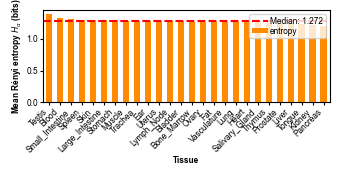

In [34]:
# fig, ax = plt.subplots(figsize=(4, 1.5))
# tissue_mean_n_iso.plot(kind="barh", ax=ax, color="darkorange", width=0.9)
# ax.axvline(median_tissue_iso, color="red", linestyle="--", label=f"Median: {median_tissue_iso:.1f}")
# ax.set_xlabel("Mean number of isoforms per gene")
# ax.set_ylabel("Tissue")
# ax.margins(y=0.005)
# ax.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(1.2, 2.8))
# tissue_mean.plot(kind="barh", ax=ax, color="darkorange", width=0.6)
# ax.axvline(median_tissue_entropy, color="red", linestyle="--", label=f"Median: {median_tissue_entropy:.3f}")
# ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
# ax.set_ylabel("Tissue")
# ax.margins(y=0.005)
# ax.legend()
# plt.savefig(figpath("renyi_acorss_tissues.pdf"))

fig, ax = plt.subplots(figsize=(3.7, 1.2))
tissue_mean.plot(kind="bar", ax=ax, color="darkorange", width=0.6)
ax.axhline(median_tissue_entropy, color="red", linestyle="--", label=f"Median: {median_tissue_entropy:.3f}")
ax.set_ylabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_xlabel("Tissue")
plt.xticks(rotation=45, ha="right")
# ax.margins(y=0.005)
ax.legend(loc = "upper right")
plt.savefig(figpath("renyi_acorss_tissues.pdf"))


#7. Scatter: entropy in cell type A vs cell type B

In [35]:
# Mean Rényi entropy per cell type (computed in section 5)
ct_mean_entropy = entropy_df.groupby("cell_ontology_class")["entropy"].mean().sort_values(ascending=False)

# cell_ontology_class -> broad_cell_class maps (load standard mapping CSVs, as in 01_08)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

# Map popv_prediction -> broad_cell_class (via popv_to_ts_map then ts_broad_map)
ct_to_broad = {ct: ts_broad_map.get(ct, "unknown")
               for ct in ct_mean_entropy.index}

# --- Left plot: top two highest mean entropy from the SAME broad_cell_class ---
same_pair = None
for i, ct_a in enumerate(ct_mean_entropy.index):
    for ct_b in ct_mean_entropy.index[i + 1:]:
        if ct_to_broad[ct_a] == ct_to_broad[ct_b] and ct_to_broad[ct_a] != "unknown":
            same_pair = [ct_a, ct_b]
            break
    if same_pair is not None:
        break

# --- Right plot: top two highest mean entropy from DIFFERENT broad_cell_classes ---
diff_pair = None
for i, ct_a in enumerate(ct_mean_entropy.index):
    for ct_b in ct_mean_entropy.index[i + 9:]:
        if ct_to_broad[ct_a] != ct_to_broad[ct_b]:
            diff_pair = [ct_a, ct_b]
            break
    if diff_pair is not None:
        break

print(f"Same broad class ({ct_to_broad[same_pair[0]]}):")
print(f"  {same_pair[0]} (mean H = {ct_mean_entropy[same_pair[0]]:.3f})")
print(f"  {same_pair[1]} (mean H = {ct_mean_entropy[same_pair[1]]:.3f})")
print(f"\nDifferent broad classes:")
print(f"  {diff_pair[0]} [{ct_to_broad[diff_pair[0]]}] (mean H = {ct_mean_entropy[diff_pair[0]]:.3f})")
print(f"  {diff_pair[1]} [{ct_to_broad[diff_pair[1]]}] (mean H = {ct_mean_entropy[diff_pair[1]]:.3f})")


Same broad class (male germ cell):
  spermatocyte (mean H = 1.371)
  spermatid (mean H = 1.349)

Different broad classes:
  spermatocyte [male germ cell] (mean H = 1.371)
  endothelial cell [endothelial cell] (mean H = 1.308)


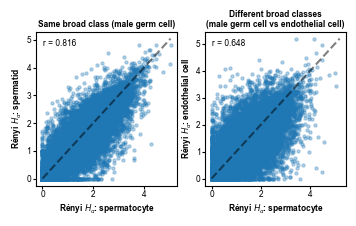

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

# --- Plot 1: Same broad class ---
ax = axes[0]
ent_pivot1 = entropy_df[entropy_df["cell_ontology_class"].isin(same_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="entropy"
).dropna()
ax.scatter(ent_pivot1[same_pair[0]], ent_pivot1[same_pair[1]], alpha=0.3, s=5)
lims = [0, max(ent_pivot1.max())]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel(f"Rényi $H_\\alpha$: {same_pair[0]}")
ax.set_ylabel(f"Rényi $H_\\alpha$: {same_pair[1]}")
ax.set_title(f"Same broad class ({ct_to_broad[same_pair[0]]})")
r1 = ent_pivot1.corr().iloc[0, 1]
ax.text(0.05, 0.95, f"r = {r1:.3f}", transform=ax.transAxes, va="top")

# --- Plot 2: Different broad classes ---
ax = axes[1]
ent_pivot2 = entropy_df[entropy_df["cell_ontology_class"].isin(diff_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="entropy"
).dropna()
ax.scatter(ent_pivot2[diff_pair[0]], ent_pivot2[diff_pair[1]], alpha=0.3, s=5)
lims = [0, max(ent_pivot2.max())]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel(f"Rényi $H_\\alpha$: {diff_pair[0]}")
ax.set_ylabel(f"Rényi $H_\\alpha$: {diff_pair[1]}")
ax.set_title(f"Different broad classes\n({ct_to_broad[diff_pair[0]]} vs {ct_to_broad[diff_pair[1]]})")
r2 = ent_pivot2.corr().iloc[0, 1]
ax.text(0.05, 0.95, f"r = {r2:.3f}", transform=ax.transAxes, va="top")

plt.savefig(figpath("04_05_renyi_scatter_celltype_pairs.pdf"))
plt.show()


#8. Genes with high between-cell-type entropy variance

In [37]:
# Per-gene Rényi entropy variance across cell types
gene_var = entropy_df.groupby("gene").agg(
    mean_entropy=("entropy", "mean"),
    var_entropy=("entropy", "var"),
    n_isoforms=("n_isoforms", "first"),  # total annotated isoforms (constant per gene)
    mean_n_expressed=("n_expressed_isoforms", "mean"),  # mean # detected isoforms across cell types
).reset_index()
gene_var = gene_var.dropna(subset=["var_entropy"])          # genes present in >=2 cell types
gene_var = gene_var.sort_values("var_entropy", ascending=False)

# Compute mean dominant isoform proportion per gene (mean of max isoform fraction across expressing cells)
mean_max_frac_dict = {}
for g_idx in range(n_genes_unique):
    col_idx = gene_col_indices[g_idx]
    if len(col_idx) < 2:
        continue
    gene_fracs = frac_csc[:, col_idx]
    row_has_expr = np.array(gene_fracs.sum(axis=1)).ravel() > 0
    if row_has_expr.sum() < 5:
        continue
    mean_fracs = np.array(gene_fracs[row_has_expr].mean(axis=0)).ravel()
    mean_max_frac_dict[unique_genes[g_idx]] = mean_fracs.max()

gene_var["mean_max_isoform_proportion"] = gene_var["gene"].map(mean_max_frac_dict)

# Helper: select genes to label — top by var_entropy from each quartile of x
def select_label_genes(df, x_col, n_per_quartile=2):
    """Pick top var_entropy genes from each quartile of x_col."""
    quartile_labels = pd.qcut(df[x_col], q=4, labels=False, duplicates="drop")
    parts = []
    for q in sorted(quartile_labels.unique()):
        q_df = df[quartile_labels == q]
        parts.append(q_df.nlargest(n_per_quartile, "var_entropy"))
    return pd.concat(parts).drop_duplicates(subset="gene"), quartile_labels

# Select genes for labeling on scatter; also keep quartile labels for stacked bar selection
scatter_label_genes, _quartile_labels = select_label_genes(gene_var, "mean_entropy")

# Top 1 per quartile for stacked bars
stacked_bar_genes = []
for q in sorted(_quartile_labels.unique()):
    q_df = gene_var[_quartile_labels == q]
    stacked_bar_genes.append(q_df.nlargest(1, "var_entropy"))
stacked_bar_genes = pd.concat(stacked_bar_genes)

# --- Quadrant thresholds (median split of mean H and Var(H)) ---
mean_thr = gene_var["mean_entropy"].median()
var_thr = gene_var["var_entropy"].median()

# Assign each gene to a quadrant and report counts (confirms all four are populated)
hi_mean = gene_var["mean_entropy"] >= mean_thr
hi_var = gene_var["var_entropy"] >= var_thr
gene_var["quadrant"] = np.select(
    [hi_mean & ~hi_var, hi_mean & hi_var, ~hi_mean & hi_var, ~hi_mean & ~hi_var],
    ["high mean / low var", "high mean / high var", "low mean / high var", "low mean / low var"],
    default="unknown",
)
print("Genes per quadrant (median split):")
print(gene_var["quadrant"].value_counts().to_string())


Genes per quadrant (median split):
quadrant
high mean / high var    8706
low mean / low var      8703
low mean / high var     4338
high mean / low var     4336



n_isoforms distribution among top 100 high-variance genes:
count    100.000000
mean      20.760000
std       17.491193
min        4.000000
25%       10.000000
50%       16.000000
75%       26.250000
max      113.000000

n_isoforms=2 genes: 2886 / 26083 (11.1%)


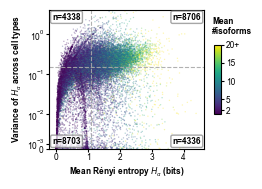

In [38]:
from adjustText import adjust_text

# --- Scatter: mean_entropy vs var_entropy, colored by n_isoforms ---
fig, ax = plt.subplots(figsize=(2.5, 1.8))

# Cap colorbar at a reasonable max for visibility
n_iso_capped = gene_var["mean_n_expressed"].clip(upper=20)
sc_plot = ax.scatter(gene_var["mean_entropy"], gene_var["var_entropy"],
                     c=n_iso_capped, cmap="viridis", alpha=0.35, s=1,
                     linewidths=0)

# Quadrant divider lines at the medians
ax.axvline(mean_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)
ax.axhline(var_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)

# Symlog y-axis: Var(H) is right-skewed across orders of magnitude (symlog handles exact zeros)
_pos_var = gene_var.loc[gene_var["var_entropy"] > 0, "var_entropy"]
_linthresh = float(_pos_var.quantile(0.05)) if len(_pos_var) else 1e-4
ax.set_yscale("symlog", linthresh=_linthresh, linscale=0.5)
ax.set_ylim(bottom=0)

# Annotate quadrant counts in the four corners
qcounts = gene_var["quadrant"].value_counts()
corner_kw = dict(fontsize=6, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.7))
ax.text(0.98, 0.98, f"n={qcounts.get('high mean / high var', 0)}",
        transform=ax.transAxes, ha="right", va="top", **corner_kw)
ax.text(0.02, 0.98, f"n={qcounts.get('low mean / high var', 0)}",
        transform=ax.transAxes, ha="left", va="top", **corner_kw)
ax.text(0.98, 0.02, f"n={qcounts.get('high mean / low var', 0)}",
        transform=ax.transAxes, ha="right", va="bottom", **corner_kw)
ax.text(0.02, 0.02, f"n={qcounts.get('low mean / low var', 0)}",
        transform=ax.transAxes, ha="left", va="bottom", **corner_kw)

ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_ylabel("Variance of $H_\\alpha$ across cell types")
# ax.set_title("Entropy variance vs mean entropy")
cbar = plt.colorbar(sc_plot, ax=ax, label="Mean # detected isoforms", shrink=0.5, aspect = 10)
cbar.set_ticks([2, 5, 10, 15, 20])
cbar.set_ticklabels(["2", "5", "10", "15", "20+"])
cbar.solids.set(alpha=1.0)
cbar.set_label("Mean\n#isoforms", rotation=0, labelpad=-20, y=1.4, ha="left")
# plt.show()
plt.savefig(figpath("renyi_entropy_mean_vs_variance.pdf"))
# Distribution of n_isoforms among top-variance genes
print("\nn_isoforms distribution among top 100 high-variance genes:")
print(gene_var.head(100)["n_isoforms"].describe().to_string())
print(f"\nn_isoforms=2 genes: {(gene_var['n_isoforms'] == 2).sum()} / {len(gene_var)} "
      f"({(gene_var['n_isoforms'] == 2).mean():.1%})")


n_isoforms distribution among top 100 high-variance genes:
count    100.000000
mean      20.760000
std       17.491193
min        4.000000
25%       10.000000
50%       16.000000
75%       26.250000
max      113.000000

n_isoforms=2 genes: 2886 / 26083 (11.1%)


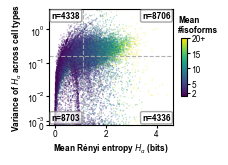

In [46]:
from adjustText import adjust_text

# --- Scatter: mean_entropy vs var_entropy, colored by n_isoforms ---
fig, ax = plt.subplots(figsize=(2.0, 1.5))

# Cap colorbar at a reasonable max for visibility
n_iso_capped = gene_var["mean_n_expressed"].clip(upper=20)
sc_plot = ax.scatter(gene_var["mean_entropy"], gene_var["var_entropy"],
                     c=n_iso_capped, cmap="viridis", alpha=0.35, s=1,
                     linewidths=0)

# Quadrant divider lines at the medians
ax.axvline(mean_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)
ax.axhline(var_thr, color="darkgrey", linestyle="--", linewidth=0.8, alpha=0.9)

# Symlog y-axis: Var(H) is right-skewed across orders of magnitude (symlog handles exact zeros)
_pos_var = gene_var.loc[gene_var["var_entropy"] > 0, "var_entropy"]
_linthresh = float(_pos_var.quantile(0.05)) if len(_pos_var) else 1e-4
ax.set_yscale("symlog", linthresh=_linthresh, linscale=0.5)
ax.set_ylim(bottom=0)

# Annotate quadrant counts in the four corners
qcounts = gene_var["quadrant"].value_counts()
corner_kw = dict(fontsize=6, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.7))
ax.text(0.98, 0.98, f"n={qcounts.get('high mean / high var', 0)}",
        transform=ax.transAxes, ha="right", va="top", **corner_kw)
ax.text(0.02, 0.98, f"n={qcounts.get('low mean / high var', 0)}",
        transform=ax.transAxes, ha="left", va="top", **corner_kw)
ax.text(0.98, 0.02, f"n={qcounts.get('high mean / low var', 0)}",
        transform=ax.transAxes, ha="right", va="bottom", **corner_kw)
ax.text(0.02, 0.02, f"n={qcounts.get('low mean / low var', 0)}",
        transform=ax.transAxes, ha="left", va="bottom", **corner_kw)

ax.set_xlabel("Mean Rényi entropy $H_\\alpha$ (bits)")
ax.set_ylabel("Variance of $H_\\alpha$ across cell types")
# ax.set_title("Entropy variance vs mean entropy")
cbar = plt.colorbar(sc_plot, ax=ax, label="Mean # detected isoforms", shrink=0.5, aspect = 10)
cbar.set_ticks([2, 5, 10, 15, 20])
cbar.set_ticklabels(["2", "5", "10", "15", "20+"])
cbar.solids.set(alpha=1.0)
cbar.set_label("Mean\n#isoforms", rotation=0, labelpad=-20, y=1.4, ha="left")
# plt.show()
plt.savefig(figpath("renyi_entropy_mean_vs_variance.pdf"))
# Distribution of n_isoforms among top-variance genes
print("\nn_isoforms distribution among top 100 high-variance genes:")
print(gene_var.head(100)["n_isoforms"].describe().to_string())
print(f"\nn_isoforms=2 genes: {(gene_var['n_isoforms'] == 2).sum()} / {len(gene_var)} "
      f"({(gene_var['n_isoforms'] == 2).mean():.1%})")

#### Gene biotype composition per quadrant (unnormalized)


In [39]:
# Gene-biotype composition per quadrant (UNNORMALIZED gene_var), using the gene_biotype file.
quadrant_order = ["high mean / low var", "high mean / high var",
                  "low mean / high var", "low mean / low var"]

# gene -> gene_biotype maps (by symbol, with ENSG fallback)
_bt = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
_name_bt = dict(zip(_bt["gene_name"].astype(str), _bt["gene_biotype"].astype(str)))
_ensg_bt = dict(zip(_bt["gene_id"].astype(str).str.replace(r"\..*", "", regex=True),
                    _bt["gene_biotype"].astype(str)))

def gene_to_biotype(g):
    g = str(g)
    if g in _name_bt:
        return _name_bt[g]
    return _ensg_bt.get(g.split(".")[0], "unknown")

gv = gene_var.copy()
if "quadrant" not in gv.columns:
    _hi_m = gv["mean_entropy"] >= gv["mean_entropy"].median()
    _hi_v = gv["var_entropy"] >= gv["var_entropy"].median()
    gv["quadrant"] = np.select(
        [_hi_m & ~_hi_v, _hi_m & _hi_v, ~_hi_m & _hi_v, ~_hi_m & ~_hi_v],
        quadrant_order, default="unknown")
gv["biotype"] = gv["gene"].map(gene_to_biotype)

# Consistent categories/colors: keep the globally most common biotypes, collapse rest to "other"
TOP_BIOTYPES = 6
_top_bt = gv["biotype"].value_counts().head(TOP_BIOTYPES).index.tolist()
gv["biotype_grp"] = gv["biotype"].where(gv["biotype"].isin(_top_bt), "other")
categories = _top_bt + (["other"] if (gv["biotype_grp"] == "other").any() else [])
_cmap = plt.cm.get_cmap("tab10", max(len(categories), 10))
biotype_color = {c: _cmap(i) for i, c in enumerate(categories)}

# Counts table (all biotypes, not collapsed)
bt_table = gv.groupby("quadrant")["biotype"].value_counts().unstack(fill_value=0)
print("Gene biotype counts per quadrant:")
print(bt_table.reindex(quadrant_order).to_string())


Gene biotype counts per quadrant:
biotype               IG_C_gene  IG_C_pseudogene  IG_V_gene  IG_V_pseudogene  TEC  TR_C_gene  TR_V_gene  TR_V_pseudogene  artifact  lncRNA  misc_RNA  processed_pseudogene  protein_coding  ribozyme  snoRNA  transcribed_processed_pseudogene  transcribed_unitary_pseudogene  transcribed_unprocessed_pseudogene  translated_unprocessed_pseudogene  unitary_pseudogene  unknown  unprocessed_pseudogene
quadrant                                                                                                                                                                                                                                                                                                                                                                                                  
high mean / low var           0                0          0                0    6          0          1                0         1    1395         1                    15      

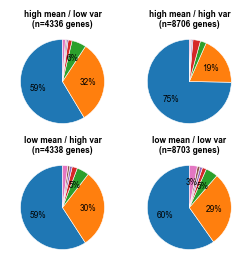

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(3, 3))
for ax, q in zip(axes.ravel(), quadrant_order):
    sub = gv[gv["quadrant"] == q]
    vc = sub["biotype_grp"].value_counts().reindex(categories).fillna(0)
    vc = vc[vc > 0]
    ax.pie(vc.values, #labels=vc.index,
           colors=[biotype_color[c] for c in vc.index],
           autopct=lambda p: f"{p:.0f}%" if p >= 3 else "",
           startangle=90, textprops={"fontsize": 6},
           wedgeprops={"linewidth": 0.4, "edgecolor": "white"})
    ax.set_title(f"{q}\n(n={len(sub)} genes)", fontsize=6, pad=0.0)

# fig.suptitle("Gene biotype composition per quadrant (unnormalized $H_\\alpha$)", y=0.9)
fig.savefig(figpath("04_05_quadrant_biotype_pies_unnormalized.pdf"))
# plt.show()

In [42]:
# Stacked bar: isoform proportions for one example gene from EACH mean/variance quadrant.
# Example = the "corner-most" gene in each quadrant (well-populated: >= 10 cell types).
# Runs for both the normalized (evenness J) and unnormalized (raw H) quadrant definitions.
from scipy.sparse import issparse as _issparse

max_isoforms = 8
quadrant_order = ["high mean / low var", "high mean / high var",
                  "low mean / high var", "low mean / low var"]

# Option: restrict the per-quadrant EXAMPLE gene selection to protein-coding genes only
# (independent of the global PROTEIN_CODING_ONLY; the quadrant analysis itself is unchanged).
EXAMPLE_PROTEIN_CODING_ONLY = True
if EXAMPLE_PROTEIN_CODING_ONLY:
    _btx = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")
    _pcx = _btx.loc[_btx["gene_biotype"].astype(str) == "protein_coding"]
    _pc_names_x = set(_pcx["gene_name"].dropna().astype(str))
    _pc_ids_x = set(_pcx["gene_id"].astype(str).str.replace(r"\..*", "", regex=True))
    if gene_col == "associated_gene":
        _is_pc = lambda g: str(g).split(".")[0] in _pc_ids_x
    else:
        _is_pc = lambda g: str(g) in _pc_names_x

# Shared precomputation (independent of which metric's quadrants we use)
_count_mat = adata.X
count_csc = _count_mat.tocsc() if _issparse(_count_mat) else _count_mat
popv = adata.obs["cell_ontology_class"].values
_n_ct = entropy_df.groupby("gene").size()


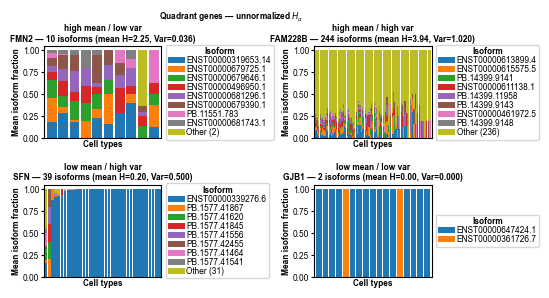

In [43]:
def pick_quadrant_examples(gv):
    """One corner-most, well-populated (>=10 cell types) gene per quadrant."""
    gv = gv.copy()
    if "quadrant" not in gv.columns:
        hi_m = gv["mean_entropy"] >= gv["mean_entropy"].median()
        hi_v = gv["var_entropy"] >= gv["var_entropy"].median()
        gv["quadrant"] = np.select(
            [hi_m & ~hi_v, hi_m & hi_v, ~hi_m & hi_v, ~hi_m & ~hi_v],
            quadrant_order, default="unknown")
    cand = gv.copy()
    cand["n_celltypes"] = cand["gene"].map(_n_ct)
    cand = cand[cand["n_celltypes"] >= 10]
    if EXAMPLE_PROTEIN_CODING_ONLY:
        cand = cand[cand["gene"].map(_is_pc)]
    r_mean = cand["mean_entropy"].rank(pct=True)
    r_var = cand["var_entropy"].rank(pct=True)
    corner_score = {
        "high mean / low var": r_mean * (1 - r_var),
        "high mean / high var": r_mean * r_var,
        "low mean / high var": (1 - r_mean) * r_var,
        "low mean / low var": (1 - r_mean) * (1 - r_var),
    }
    picks = []
    for q in quadrant_order:
        sub = cand[cand["quadrant"] == q]
        if sub.empty:
            sub = gv[gv["quadrant"] == q]
            if EXAMPLE_PROTEIN_CODING_ONLY:
                sub = sub[sub["gene"].map(_is_pc)]
            if sub.empty:
                continue
            picks.append((q, sub.iloc[0]))
            continue
        best_idx = corner_score[q].loc[sub.index].idxmax()
        picks.append((q, cand.loc[best_idx]))
    return picks

def plot_quadrant_examples(gv, metric_short, save_name):
    example_genes = pick_quadrant_examples(gv)
    fig, axes = plt.subplots(2, 2, figsize=(5, 3.0))
    for idx, (quadrant, gene_row) in enumerate(example_genes):
        ax = axes[idx // 2, idx % 2]
        gene_name = gene_row["gene"]

        gene_iso_mask = adata.var[gene_col].values == gene_name
        gene_iso_idx = np.where(gene_iso_mask)[0]
        gene_iso_names = adata.var.index[gene_iso_mask].tolist()

        # Slice this gene's isoform COLUMNS once (fast on CSC), then densify the small block.
        Fg = frac_csc[:, gene_iso_idx]
        Fg = Fg.toarray() if _issparse(Fg) else np.asarray(Fg)
        Cg = count_csc[:, gene_iso_idx]
        Cg = Cg.toarray() if _issparse(Cg) else np.asarray(Cg)

        gene_entropy_sub = entropy_df[entropy_df["gene"] == gene_name].sort_values("entropy", ascending=False)
        gene_cts = gene_entropy_sub["cell_ontology_class"].tolist()

        frac_records = []
        count_records = []
        for ct in gene_cts:
            m = popv == ct
            subF = Fg[m]
            expressing = subF.sum(axis=1) > 0
            if expressing.sum() < 5:
                continue
            mean_fracs = subF[expressing].mean(axis=0)
            total_counts = Cg[m][expressing].sum(axis=0)
            for j, iso in enumerate(gene_iso_names):
                frac_records.append({"cell_ontology_class": ct, "isoform": iso, "mean_fraction": mean_fracs[j]})
                count_records.append({"cell_ontology_class": ct, "isoform": iso, "total_count": int(total_counts[j])})

        frac_df = pd.DataFrame(frac_records)
        frac_pivot = frac_df.pivot_table(index="cell_ontology_class", columns="isoform", values="mean_fraction", fill_value=0)
        count_df_pivot = pd.DataFrame(count_records).pivot_table(index="cell_ontology_class", columns="isoform", values="total_count", fill_value=0)

        iso_means = frac_pivot.mean(axis=0).sort_values(ascending=False)
        top_isos = iso_means.head(max_isoforms).index.tolist()
        other_cols = [c for c in frac_pivot.columns if c not in top_isos]
        plot_df = frac_pivot[top_isos].copy()
        count_plot = count_df_pivot.reindex(columns=top_isos, fill_value=0).copy()
        if len(other_cols) > 0:
            other_sum = frac_pivot[other_cols].sum(axis=1)
            other_count_sum = count_df_pivot[[c for c in other_cols if c in count_df_pivot.columns]].sum(axis=1)
            if other_sum.sum() > 0:
                plot_df["Other"] = other_sum
                count_plot["Other"] = other_count_sum

        ct_order = [ct for ct in gene_cts if ct in plot_df.index]
        plot_df = plot_df.reindex(ct_order)
        count_plot = count_plot.reindex(ct_order)

        plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=False)

        # for i, col in enumerate(plot_df.columns):
        #     container = ax.containers[i]
        #     for j, bar in enumerate(container):
        #         count_val = int(count_plot.iloc[j, i])
        #         if count_val > 0 and bar.get_height() > 0.05:
        #             cx = bar.get_x() + bar.get_width() / 2
        #             cy = bar.get_y() + bar.get_height() / 2
        #             ax.text(cx, cy, f"{count_val:,}", ha="center", va="center", fontsize=7, color="black")

        ax.set_xlabel("Cell types")
        ax.set_ylabel("Mean isoform fraction")
        ax.set_xticks([])   
        ax.set_title(f"{quadrant}\n{gene_name} — {len(gene_iso_names)} isoforms "
                     f"(mean {metric_short}={gene_row['mean_entropy']:.2f}, Var={gene_row['var_entropy']:.3f})",
                     pad=PANEL_TITLE_PAD)
        # ax.tick_params(axis="x", rotation=45)
        # for label in ax.get_xticklabels():
        #     label.set_ha("right")
        #     label.set_fontsize(6)
        other_count = len(other_cols)
        legend_labels = list(plot_df.columns[:-1]) + [f"Other ({other_count})"] if "Other" in plot_df.columns else list(plot_df.columns)
        leg = ax.legend(legend_labels, title = "Isoform", 
                  loc=6, bbox_to_anchor=(1.0, 0.5), labelspacing = 0.0, 
                  ncol=1)
        leg.get_title().set_fontweight("bold")

    metric_name = {"J": "normalized evenness $J_\\alpha$", "H": "unnormalized $H_\\alpha$"}.get(metric_short, metric_short)
    fig.suptitle(f"Quadrant genes — {metric_name}", y=1.00)
    plt.subplots_adjust(wspace = 1.3, hspace = 0.5)
    fig.savefig(save_name)
    plt.show()

# Unnormalized (raw H) quadrants
plot_quadrant_examples(gene_var, "H",
                       figpath("04_05_quadrant_example_genes_stackedbar_unnormalized.pdf"))


#11. Matrix-based Rényi entropy

The scalar Rényi entropy in section 3 is computed on the **mean** isoform-fraction vector across cells of a cell type — it captures the centroid of usage but is blind to per-cell heterogeneity. Matrix-based Rényi entropy (Sanchez Giraldo, Rao & Príncipe 2014) operates on the eigenvalues of a normalized Gram matrix:

$$S_\alpha(A) = \frac{1}{1-\alpha} \log_2 \sum_i \lambda_i(A)^\alpha,\quad A = \frac{X^\top X}{\mathrm{tr}(X^\top X)}$$

where $X \in \mathbb{R}^{N_{cells} \times k_{iso}}$ stacks per-cell isoform fractions for one gene in one cell type. Because $X^\top X$ is $k \times k$ (typically $k \le 20$), this is fast.

Interpretation:
- $S_\alpha$ measures the **effective rank** of the cell-by-isoform usage matrix.
- A cell type where every cell uses one isoform but different cells pick different isoforms gets a *high* $S_\alpha$ (correctly reflects per-cell heterogeneity), whereas the scalar Rényi on the mean would also be high but for the wrong reason (the mean only *appears* balanced).
- Disagreement between scalar and matrix Rényi flags cell types with **bimodal/heterogeneous** isoform usage rather than uniform within-cell mixing.


In [33]:
import os
from concurrent.futures import ProcessPoolExecutor
try:
    from threadpoolctl import threadpool_limits
except Exception:                       # graceful fallback if threadpoolctl is absent
    from contextlib import nullcontext
    def threadpool_limits(*a, **k):
        return nullcontext()
from numpy.linalg import eigvalsh


def matrix_renyi_from_eigs(eigs, alpha):
    """Rényi entropy from eigenvalues (already normalized to sum to 1)."""
    eigs = eigs[eigs > 1e-12]
    if len(eigs) == 0:
        return 0.0
    if np.isclose(alpha, 1.0):
        return float(-np.sum(eigs * np.log2(eigs)))
    if np.isinf(alpha):
        return float(-np.log2(np.max(eigs)))
    return float(np.log2(np.sum(np.power(eigs, alpha))) / (1.0 - alpha))


# Per (gene, cell type): build X (cells x isoforms) from the isoform_fraction layer, restrict
# to expressing cells, compute eigenvalues of X^T X / tr(X^T X), then S_alpha. The work is
# independent per cell type, so we parallelize the outer loop with a fork-based process pool:
# each worker inherits the large arrays (frac_csc, gene_col_indices, unique_genes, adata, ...)
# via copy-on-write, so only the cell-type name is sent. Worker count is clamped to the true
# CPU allocation (os.sched_getaffinity) and BLAS is pinned to 1 thread per worker
# (threadpool_limits) so we don't get the N_procs x all-core-BLAS oversubscription blowup.
def _matrix_renyi_for_celltype(ct):
    ct_mask = (adata.obs["cell_ontology_class"] == ct).values
    if ct_mask.sum() < 10:
        return []
    frac_ct = frac_csc[ct_mask, :]              # cells_in_ct x n_isoforms
    recs = []
    for g_idx in range(n_genes_unique):
        col_idx = gene_col_indices[g_idx]
        k = len(col_idx)
        if k < 2:
            continue
        X = frac_ct[:, col_idx]                 # sparse cells x k
        row_sums = np.asarray(X.sum(axis=1)).ravel()
        expr_mask = row_sums > 0
        if expr_mask.sum() < 5:
            continue
        X_e = X[expr_mask, :]
        X_dense = X_e.toarray() if issparse(X_e) else np.asarray(X_e)
        G = X_dense.T @ X_dense                  # Gram matrix between isoforms (k x k, small)
        tr = float(np.trace(G))
        if tr <= 0:
            continue
        eigs = eigvalsh(G) / tr                  # normalized eigenvalues, sum to 1
        S = matrix_renyi_from_eigs(eigs, RENYI_ALPHA)
        recs.append({"gene": unique_genes[g_idx], "cell_ontology_class": ct,
                     "matrix_entropy": S, "n_isoforms": k,
                     "n_cells_expr": int(expr_mask.sum())})
    return recs


_n_workers = max(1, min(len(cell_types), len(os.sched_getaffinity(0))))
print(f"Computing matrix-based Rényi entropy (alpha={RENYI_ALPHA}) for {n_genes_unique} genes x "
      f"{len(cell_types)} cell types on {_n_workers} worker process(es)")

matrix_records = []
with threadpool_limits(limits=1):               # 1 BLAS thread/worker -> total threads <= cores
    if _n_workers == 1:
        for ct in cell_types:
            matrix_records.extend(_matrix_renyi_for_celltype(ct))
    else:
        with ProcessPoolExecutor(max_workers=_n_workers) as _ex:
            for recs in _ex.map(_matrix_renyi_for_celltype, cell_types):
                matrix_records.extend(recs)

matrix_entropy_df = pd.DataFrame(matrix_records)
print(f"Matrix-Rényi table: {matrix_entropy_df.shape[0]} gene-celltype pairs")
print(f"S_alpha range: [{matrix_entropy_df['matrix_entropy'].min():.4f}, {matrix_entropy_df['matrix_entropy'].max():.4f}]")
matrix_entropy_df.head(10)

Computing matrix-based Rényi entropy (alpha=2) for 26940 genes x 144 cell types on 16 worker process(es)
Matrix-Rényi table: 1092139 gene-celltype pairs
S_alpha range: [-0.0000, 5.5560]


,gene,cell_ontology_class,matrix_entropy,n_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1106
1,A1BG,acinar cell of salivary gland,0.054591,9,133
2,A1BG-AS1,acinar cell of salivary gland,1.874469,20,11
3,A2M,acinar cell of salivary gland,0.487366,43,357
4,A4GALT,acinar cell of salivary gland,1.220551,22,162
5,AAAS,acinar cell of salivary gland,1.583022,24,127
6,AACS,acinar cell of salivary gland,1.374906,14,183
7,AAGAB,acinar cell of salivary gland,1.997728,18,76
8,AAK1,acinar cell of salivary gland,0.171585,32,396
9,AAMDC,acinar cell of salivary gland,2.681690,83,191


In [19]:
# # Save per-gene per-cell-type matrix-based Rényi entropy
# _csv_path_m = f"./../csvs/per_gene_celltype_isoform_diversity_matrix_renyi_alpha{RENYI_ALPHA}.csv"
# matrix_entropy_df.to_csv(_csv_path_m, index=False)
# print(f"Saved {matrix_entropy_df.shape[0]} gene-celltype pairs to {_csv_path_m}")
# matrix_entropy_df.head()

In [18]:
# Read the matrix Rényi table back, so everything below runs off the saved CSV and the
# heavy per-gene matrix computation above can be skipped on a rerun (mirrors the
# scalar-entropy reload in section 4 and the tissue-entropy reload in section 6).
_csv_path_m = f"./../csvs/per_gene_celltype_isoform_diversity_matrix_renyi_alpha{RENYI_ALPHA}.csv"
matrix_entropy_df = pd.read_csv(_csv_path_m)
print(f"Loaded {matrix_entropy_df.shape[0]} gene-celltype pairs from {_csv_path_m}")
matrix_entropy_df.head()

Loaded 1092139 gene-celltype pairs from ./../csvs/per_gene_celltype_isoform_diversity_matrix_renyi_alpha2.csv


,gene,cell_ontology_class,matrix_entropy,n_isoforms,n_cells_expr
0,7SK,acinar cell of salivary gland,-0.000000,6,1106
1,A1BG,acinar cell of salivary gland,0.054591,9,133
2,A1BG-AS1,acinar cell of salivary gland,1.874469,20,11
3,A2M,acinar cell of salivary gland,0.487366,43,357
4,A4GALT,acinar cell of salivary gland,1.220551,22,162


In [20]:
# Box plot: matrix Rényi entropy S_alpha across cell types.
# One box per cell type over its per-gene S_alpha values, ordered by median.
# Shows that within-population isoform-usage diversity differs between cell types.
ct_counts_mat = matrix_entropy_df["cell_ontology_class"].value_counts()
ct_order_mat = (matrix_entropy_df.groupby("cell_ontology_class")["matrix_entropy"]
                .median().sort_values(ascending=False).index.tolist())
# keep cell types with a reasonable number of gene observations
ct_order_mat = [ct for ct in ct_order_mat if ct_counts_mat[ct] >= 20]

box_data = [matrix_entropy_df.loc[matrix_entropy_df["cell_ontology_class"] == ct, "matrix_entropy"].values
            for ct in ct_order_mat]

print(f"{len(ct_order_mat)} cell types plotted (>= 20 gene observations each)")


128 cell types plotted (>= 20 gene observations each)


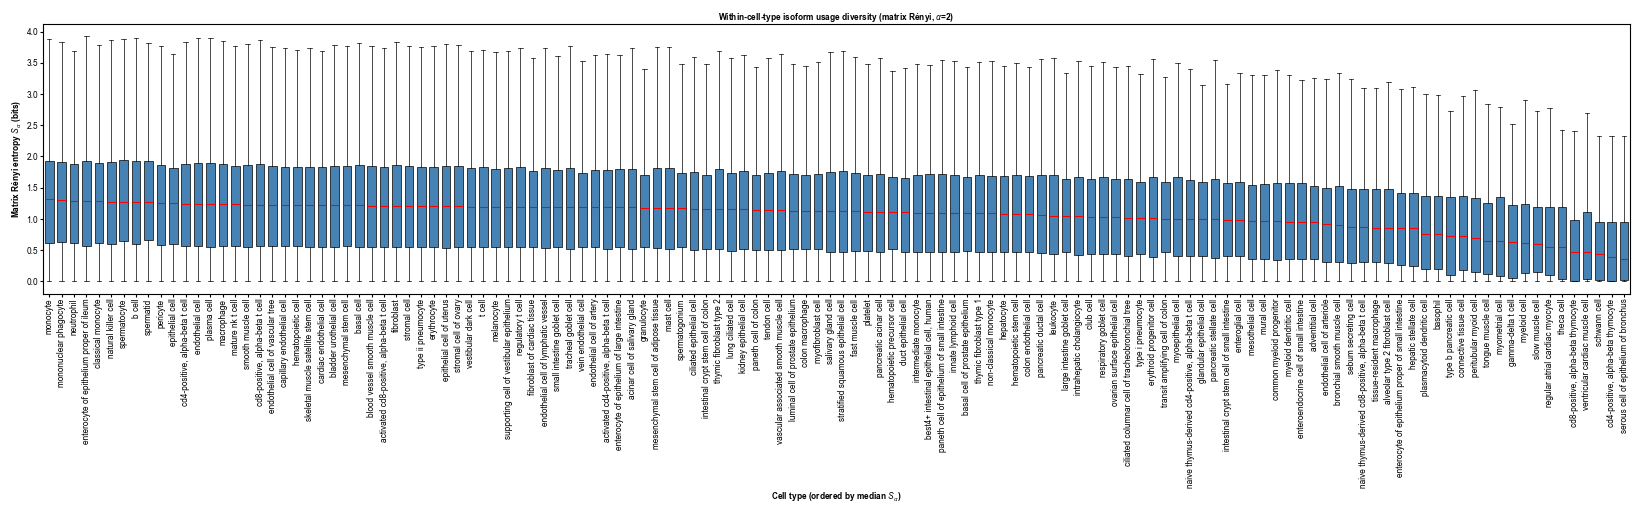

In [21]:
fig, ax = plt.subplots(figsize=(max(6, len(ct_order_mat) * 0.16), 3.5))
bp = ax.boxplot(box_data, showfliers=False, patch_artist=True, widths=0.7)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_edgecolor("black")
    patch.set_linewidth(0.5)
for element in ["whiskers", "caps"]:
    for line in bp[element]:
        line.set_linewidth(0.5)
        line.set_color("black")
for line in bp["medians"]:
    line.set_linewidth(0.75)
    line.set_color("red")

ax.set_xticks(range(1, len(ct_order_mat) + 1))
ax.set_xticklabels(ct_order_mat, rotation=90, ha="center")
ax.set_ylabel("Matrix Rényi entropy $S_\\alpha$ (bits)")
ax.set_xlabel("Cell type (ordered by median $S_\\alpha$)")
ax.set_title(f"Within-cell-type isoform usage diversity (matrix Rényi, $\\alpha$={RENYI_ALPHA})")

fig.savefig(figpath(f"04_05_matrix_renyi_boxplot_celltype_alpha{RENYI_ALPHA}.pdf"))
plt.show()


In [31]:
# Compare scalar Rényi (mean of fractions) vs matrix Rényi (eigenvalues of X^T X / tr)
compare_df = entropy_df.merge(
    matrix_entropy_df[["gene", "cell_ontology_class", "matrix_entropy"]],
    on=["gene", "cell_ontology_class"], how="inner"
)
compare_df["delta"] = compare_df["matrix_entropy"] - compare_df["entropy"]
print(f"Compared {len(compare_df)} (gene, cell_ontology_class) pairs.")
print(f"Pearson r (scalar vs matrix) = {compare_df[['entropy', 'matrix_entropy']].corr().iloc[0, 1]:.4f}")
print(f"Mean delta (matrix - scalar) = {compare_df['delta'].mean():.4f}")

# Cell types where matrix > scalar most strongly (high per-cell heterogeneity)
ct_delta = compare_df.groupby("cell_ontology_class")["delta"].agg(["mean", "median", "count"]).reset_index()
ct_delta = ct_delta[ct_delta["count"] >= 50].sort_values("mean", ascending=False)
print("\nTop 15 cell types by mean (matrix − scalar): high cell-to-cell isoform heterogeneity")
print(ct_delta.head(15).to_string(index=False))
print("\nBottom 15 cell types: usage homogeneous within cell type")
print(ct_delta.tail(15).to_string(index=False))

# Genes with biggest divergence (averaged over cell types)
gene_delta = compare_df.groupby("gene")["delta"].agg(["mean", "median", "count"]).reset_index()
gene_delta = gene_delta[gene_delta["count"] >= 5].sort_values("mean", ascending=False)
print("\nTop 20 genes where matrix Rényi >> scalar Rényi (heterogeneous per-cell usage):")
print(gene_delta.head(20).to_string(index=False))


Compared 1092139 (gene, cell_ontology_class) pairs.
Pearson r (scalar vs matrix) = 0.9974
Mean delta (matrix - scalar) = -0.0268

Top 15 cell types by mean (matrix − scalar): high cell-to-cell isoform heterogeneity
                     cell_ontology_class      mean        median  count
                   stromal cell of ovary -0.007826 -8.481778e-04  16569
                   mesenchymal stem cell -0.009156 -2.160668e-07  15274
         blood vessel smooth muscle cell -0.009418  0.000000e+00  12921
                                  b cell -0.010348 -7.265806e-04  14626
                    innate lymphoid cell -0.011765  0.000000e+00   7296
 mesenchymal stem cell of adipose tissue -0.011972 -4.189014e-04  14747
                     natural killer cell -0.012067 -1.192093e-07  12481
         cd8-positive, alpha-beta t cell -0.012103 -1.232564e-03  14646
     skeletal muscle satellite stem cell -0.012115 -1.192093e-07  12478
enterocyte of epithelium proper of ileum -0.012271 -8.029938e-04 

per-gene Pearson r = 0.9989 over 26,885 genes


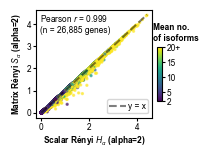

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.4))

# --- Panel 1: scalar vs matrix Rényi, ONE POINT PER GENE ---
# compare_df holds one row per (gene, cell type) PAIR. Plotting the pairs drew the same
# gene once for every cell type it is expressed in (1,092,139 points), which made the
# cloud a set of non-independent observations and did not match the per-gene r reported
# below. Averaging both estimators -- and the isoform count used for the colour --
# within a gene gives one point per gene, so the cloud and the statistic share units.
_gene_mean = compare_df.groupby("gene")[["entropy", "matrix_entropy",
                                        "n_isoforms"]].mean()
n_iso_capped = _gene_mean["n_isoforms"].clip(upper=20)
# rasterized: ~21k gene points render to ~30 KB vs ~365 KB fully vector. Only the point
# cloud is rasterized (at savefig dpi); axes, ticks, labels and the y=x line stay vector
# and editable. Set rasterized=False if you want individually selectable points.
sc_plot = ax.scatter(_gene_mean["entropy"], _gene_mean["matrix_entropy"],
                     c=n_iso_capped, cmap="viridis", alpha=0.6, s=2, rasterized=True)
lim = max(_gene_mean["entropy"].max(), _gene_mean["matrix_entropy"].max())
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="y = x")
ax.set_xlabel(f"Scalar Rényi $H_\\alpha$ (alpha={RENYI_ALPHA})")
ax.set_ylabel(f"Matrix Rényi $S_\\alpha$ (alpha={RENYI_ALPHA})")
# ax.set_title("Scalar (mean IF) vs matrix (X^T X) Rényi")
ax.legend(loc="lower right")
# Colorbar in its OWN inset axes. plt.colorbar(ax=ax) steals width from the parent
# axes, so the data panel was only 0.93 x 0.92 in inside a 1.5 x 1.2 in figure (62% of
# the requested width vs 77% of the height) -- figsize no longer described the panel,
# and panels with a colorbar came out narrower than panels without one.
# ax.inset_axes() positions the bar RELATIVE to ax without resizing it: the panel is
# now 1.16 x 0.92 in, so width and height scale the same way.
# [x0, y0, w, h] in axes fractions, chosen to reproduce the previous bar exactly
# (0.047 x 0.462 in, aspect ~10 == the old shrink=0.5 / aspect=10).
cax = ax.inset_axes([1.04, 0.15, 0.040, 0.50])
cbar = fig.colorbar(sc_plot, cax=cax)   # label set below via cbar.set_label
cbar.set_ticks([2, 5, 10, 15, 20])
cbar.set_ticklabels(["2", "5", "10", "15", "20+"])
cbar.solids.set(alpha=1.0)
cbar.set_label("Mean no.\nof isoforms", rotation=0, labelpad=-20, y=1.45, ha="left")
# # --- Panel 2: distribution of delta = matrix - scalar ---
# ax = axes[1]
# ax.hist(compare_df["delta"], bins=80, edgecolor="black", linewidth=0.4, color="grey")
# ax.axvline(0, color="black", linestyle="-", alpha=0.4)
# ax.axvline(compare_df["delta"].median(), color="red", linestyle="--",
#            label=f"Median: {compare_df['delta'].median():.3f}")
# ax.set_xlabel("Matrix $S_\\alpha$ − scalar $H_\\alpha$")
# ax.set_ylabel("Number of (gene, cell type) pairs")
# ax.set_title("Per-cell heterogeneity gap")
# ax.legend()
# plt.subplots_adjust(wspace = 0.5)

# Pearson r on the SAME per-gene values plotted above, so the statistic and the cloud
# describe the same observations (one gene = one point = one observation).
# NOTE the `renyi-mat-compare` cell prints the PAIRWISE r (0.9974) over all 1,092,139
# (gene, cell type) pairs. That is a different quantity computed on non-independent
# observations -- do not quote the two interchangeably.
# Upper-left: the legend sits lower-right and the cloud hugs y = x.
_r = _gene_mean["entropy"].corr(_gene_mean["matrix_entropy"])   # built above
print(f"per-gene Pearson r = {_r:.4f} over {len(_gene_mean):,} genes")
ax.text(0.03, 0.97, f"Pearson $r$ = {_r:.3f}\n(n = {len(_gene_mean):,} genes)",
        transform=ax.transAxes, va="top", ha="left")   # no fontsize -> inherits 6 pt

# bbox_inches stated explicitly (not just via the savefig.bbox rcParam) so the panel
# still crops correctly if this cell is run in a kernel where the formatting cell
# was not executed. dpi sets the rasterized-layer resolution.
plt.savefig(figpath("04_05_scalar_vs_matrix_renyi.pdf"), bbox_inches="tight", dpi=300)
plt.show()